# ICS1512 – Machine Learning Algorithms Laboratory
## Experiment 5: Decision Tree and Random Forest – A Comparative Classification Study

**Institution:** Sri Sivasubramaniya Nadar College of Engineering, Chennai  
**Programme:** M.Tech (Integrated) Computer Science & Engineering  
**Semester:** V  
**Subject:** ICS1512 & Machine Learning Algorithms Laboratory  
**Academic Year:** 2026–2027 (Odd)  
**Batch:** 2024–2029  
**Dataset:** Wisconsin Diagnostic Breast Cancer (WDBC)

### Objectives
- Implement a Decision Tree classifier.
- Extend the Decision Tree into a Random Forest ensemble.
- Study hyperparameters, overfitting, and generalization.
- Select hyperparameters using 5-fold cross-validation.
- Compare single-tree and ensemble-tree models.

**Reproducibility:** `random_state=42` is used throughout.


## 1. Import Libraries

In [1]:
import sys
import platform
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, roc_curve, auc, roc_auc_score

RANDOM_STATE = 42
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Scikit-learn:", sklearn.__version__)
print("Platform:", platform.platform())


Python: 3.13.15
Scikit-learn: 1.6.1
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


## 2. Load Dataset

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data.copy()
y = data.target.copy()
target_labels = {0: "Malignant", 1: "Benign"}

print("Dataset shape:", X.shape)
print("Samples:", len(X))
print("Features:", X.shape[1])
print("Classes:", data.target_names)
display(X.head())


Dataset shape: (569, 30)
Samples: 569
Features: 30
Classes: ['malignant' 'benign']


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Dataset Overview and Statistical Summary

In [3]:
print("Data types:")
display(X.dtypes.to_frame("dtype"))

print("\nStatistical summary:")
display(X.describe().T)

print("\nClass counts:")
display(y.map(target_labels).value_counts().to_frame("Count"))


Data types:


,dtype
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64



Statistical summary:


,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
mean texture,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
mean perimeter,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
mean area,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
mean smoothness,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
mean compactness,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
mean concavity,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
mean concave points,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
mean symmetry,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
mean fractal dimension,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744



Class counts:


,Count
target,
Benign,357
Malignant,212


## 4. Missing Value Analysis

In [4]:
missing = X.isnull().sum()
missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Missing Percentage": (missing / len(X) * 100).round(2)
})
display(missing_table[missing_table["Missing Values"] > 0])
print("Total missing values:", int(X.isnull().sum().sum()))


,Missing Values,Missing Percentage


Total missing values: 0


## 5. EDA – Class Distribution

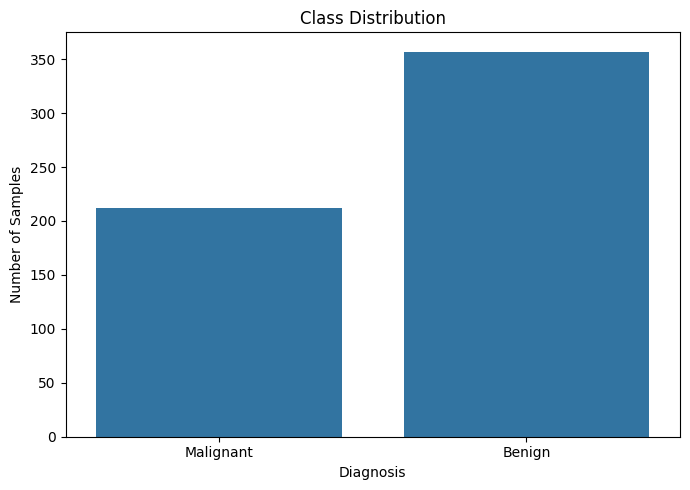

In [5]:
plt.figure(figsize=(7,5))
sns.countplot(x=y.map(target_labels))
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.savefig(FIG_DIR/"class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


**Inference:** The dataset contains malignant and benign observations with unequal frequencies. Stratified splitting and stratified cross-validation preserve class proportions, making the comparison more consistent.

## 6. EDA – Correlation Matrix

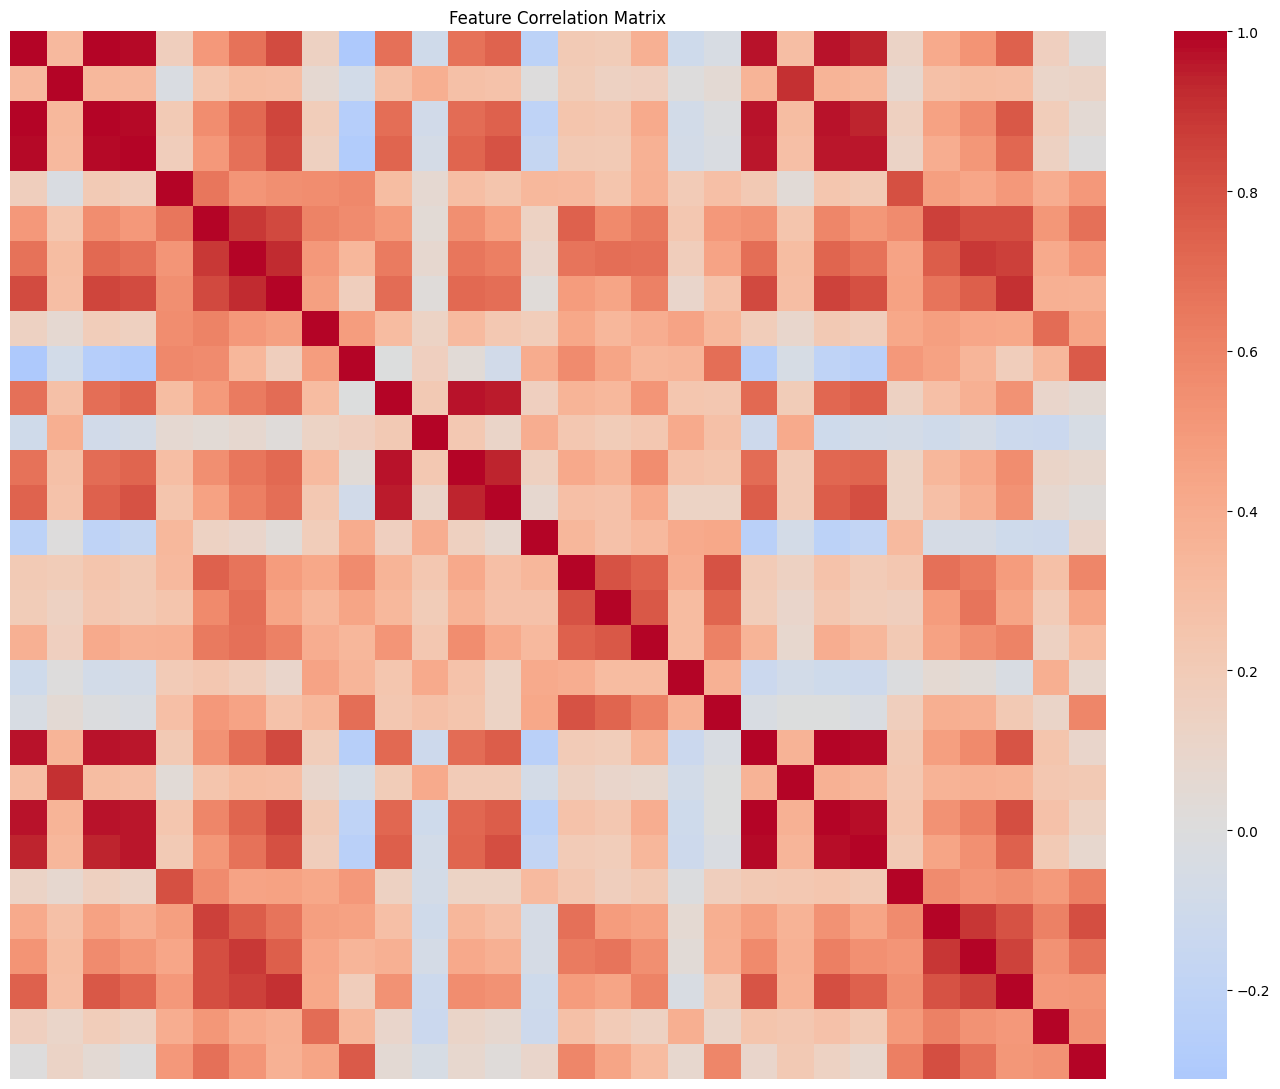

In [6]:
plt.figure(figsize=(14,11))
sns.heatmap(X.corr(), cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(FIG_DIR/"correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


**Inference:** Several measurements are strongly correlated because they describe related properties of cell nuclei. Decision Trees and Random Forests do not require feature scaling. Random Forest additionally uses random feature subsets, which increases diversity among trees.

## 7. Train-Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 455
Testing samples: 114


## 8. Baseline Decision Tree

In [8]:
baseline_dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
baseline_dt.fit(X_train, y_train)
baseline_pred = baseline_dt.predict(X_test)
baseline_prob = baseline_dt.predict_proba(X_test)[:,1]

def metrics_row(name, y_true, pred, prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true,pred),
        "Precision": precision_score(y_true,pred),
        "Recall": recall_score(y_true,pred),
        "F1 Score": f1_score(y_true,pred),
        "ROC-AUC": roc_auc_score(y_true,prob)
    }

display(pd.DataFrame([metrics_row("Baseline Decision Tree", y_test, baseline_pred, baseline_prob)]))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Baseline Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675


## 9. Decision Tree – 5-Fold Hyperparameter Search

In [9]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_grid_params = {
    "criterion": ["gini","entropy","log_loss"],
    "max_depth": [2,3,4,5,7,10,None],
    "min_samples_split": [2,5,10],
    "min_samples_leaf": [1,2,4]
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_grid = GridSearchCV(
    dt, dt_grid_params,
    scoring={"accuracy":"accuracy","f1":"f1"},
    refit="f1", cv=cv, n_jobs=-1, return_train_score=True
)
dt_grid.fit(X_train,y_train)

print("Best parameters:", dt_grid.best_params_)
print("Best mean CV F1:", dt_grid.best_score_)

dt_cv = pd.DataFrame(dt_grid.cv_results_)
dt_table = dt_cv[[
    "param_criterion","param_max_depth","param_min_samples_split",
    "param_min_samples_leaf","mean_test_accuracy","mean_test_f1",
    "std_test_accuracy","std_test_f1"
]].sort_values("mean_test_f1",ascending=False)
display(dt_table.head(15))


Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best mean CV F1: 0.9505801727040666


,param_criterion,param_max_depth,param_min_samples_split,param_min_samples_leaf,mean_test_accuracy,mean_test_f1,std_test_accuracy,std_test_f1
53,gini,10,10,4,0.938462,0.950580,0.019160,0.015243
44,gini,7,10,4,0.938462,0.950580,0.019160,0.015243
33,gini,5,2,4,0.938462,0.950580,0.019160,0.015243
35,gini,5,10,4,0.938462,0.950580,0.019160,0.015243
34,gini,5,5,4,0.938462,0.950580,0.019160,0.015243
62,gini,None,10,4,0.938462,0.950580,0.019160,0.015243
83,entropy,4,10,1,0.936264,0.948804,0.021308,0.016752
146,log_loss,4,10,1,0.936264,0.948804,0.021308,0.016752
74,entropy,3,10,1,0.934066,0.947973,0.024076,0.018223
75,entropy,3,2,2,0.934066,0.947973,0.024076,0.018223


## 10. Decision Tree – Depth Effect

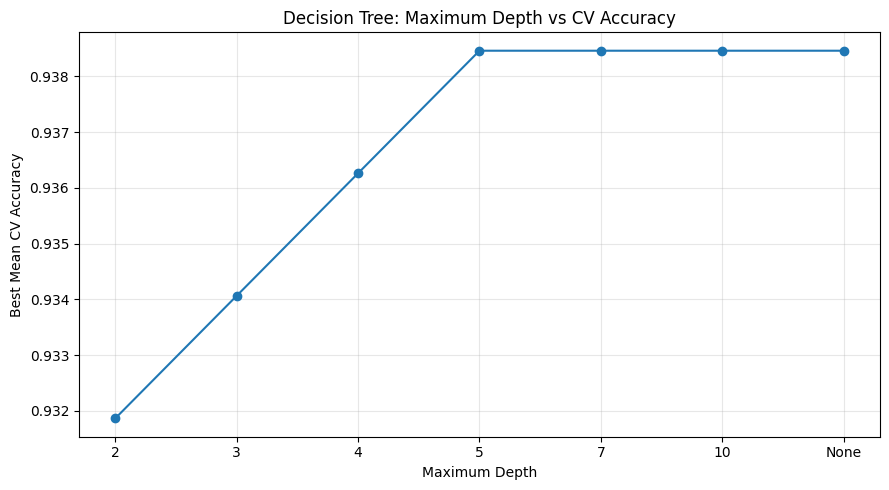

In [10]:
depth_effect = dt_cv.groupby("param_max_depth",dropna=False)["mean_test_accuracy"].max().reset_index()
depth_effect["Depth"] = depth_effect["param_max_depth"].apply(lambda x: "None" if pd.isna(x) else str(int(x)))

plt.figure(figsize=(9,5))
plt.plot(depth_effect["Depth"], depth_effect["mean_test_accuracy"], marker="o")
plt.xlabel("Maximum Depth")
plt.ylabel("Best Mean CV Accuracy")
plt.title("Decision Tree: Maximum Depth vs CV Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/"decision_tree_depth_effect.png",dpi=300,bbox_inches="tight")
plt.show()


**Inference:** Tree depth controls model complexity. Very shallow trees may underfit, while very deep trees can increase variance and overfit training-specific patterns. Cross-validation identifies a depth that balances flexibility and generalization.

## 11. Final Decision Tree

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.903509,0.942029,0.902778,0.921986,0.935847


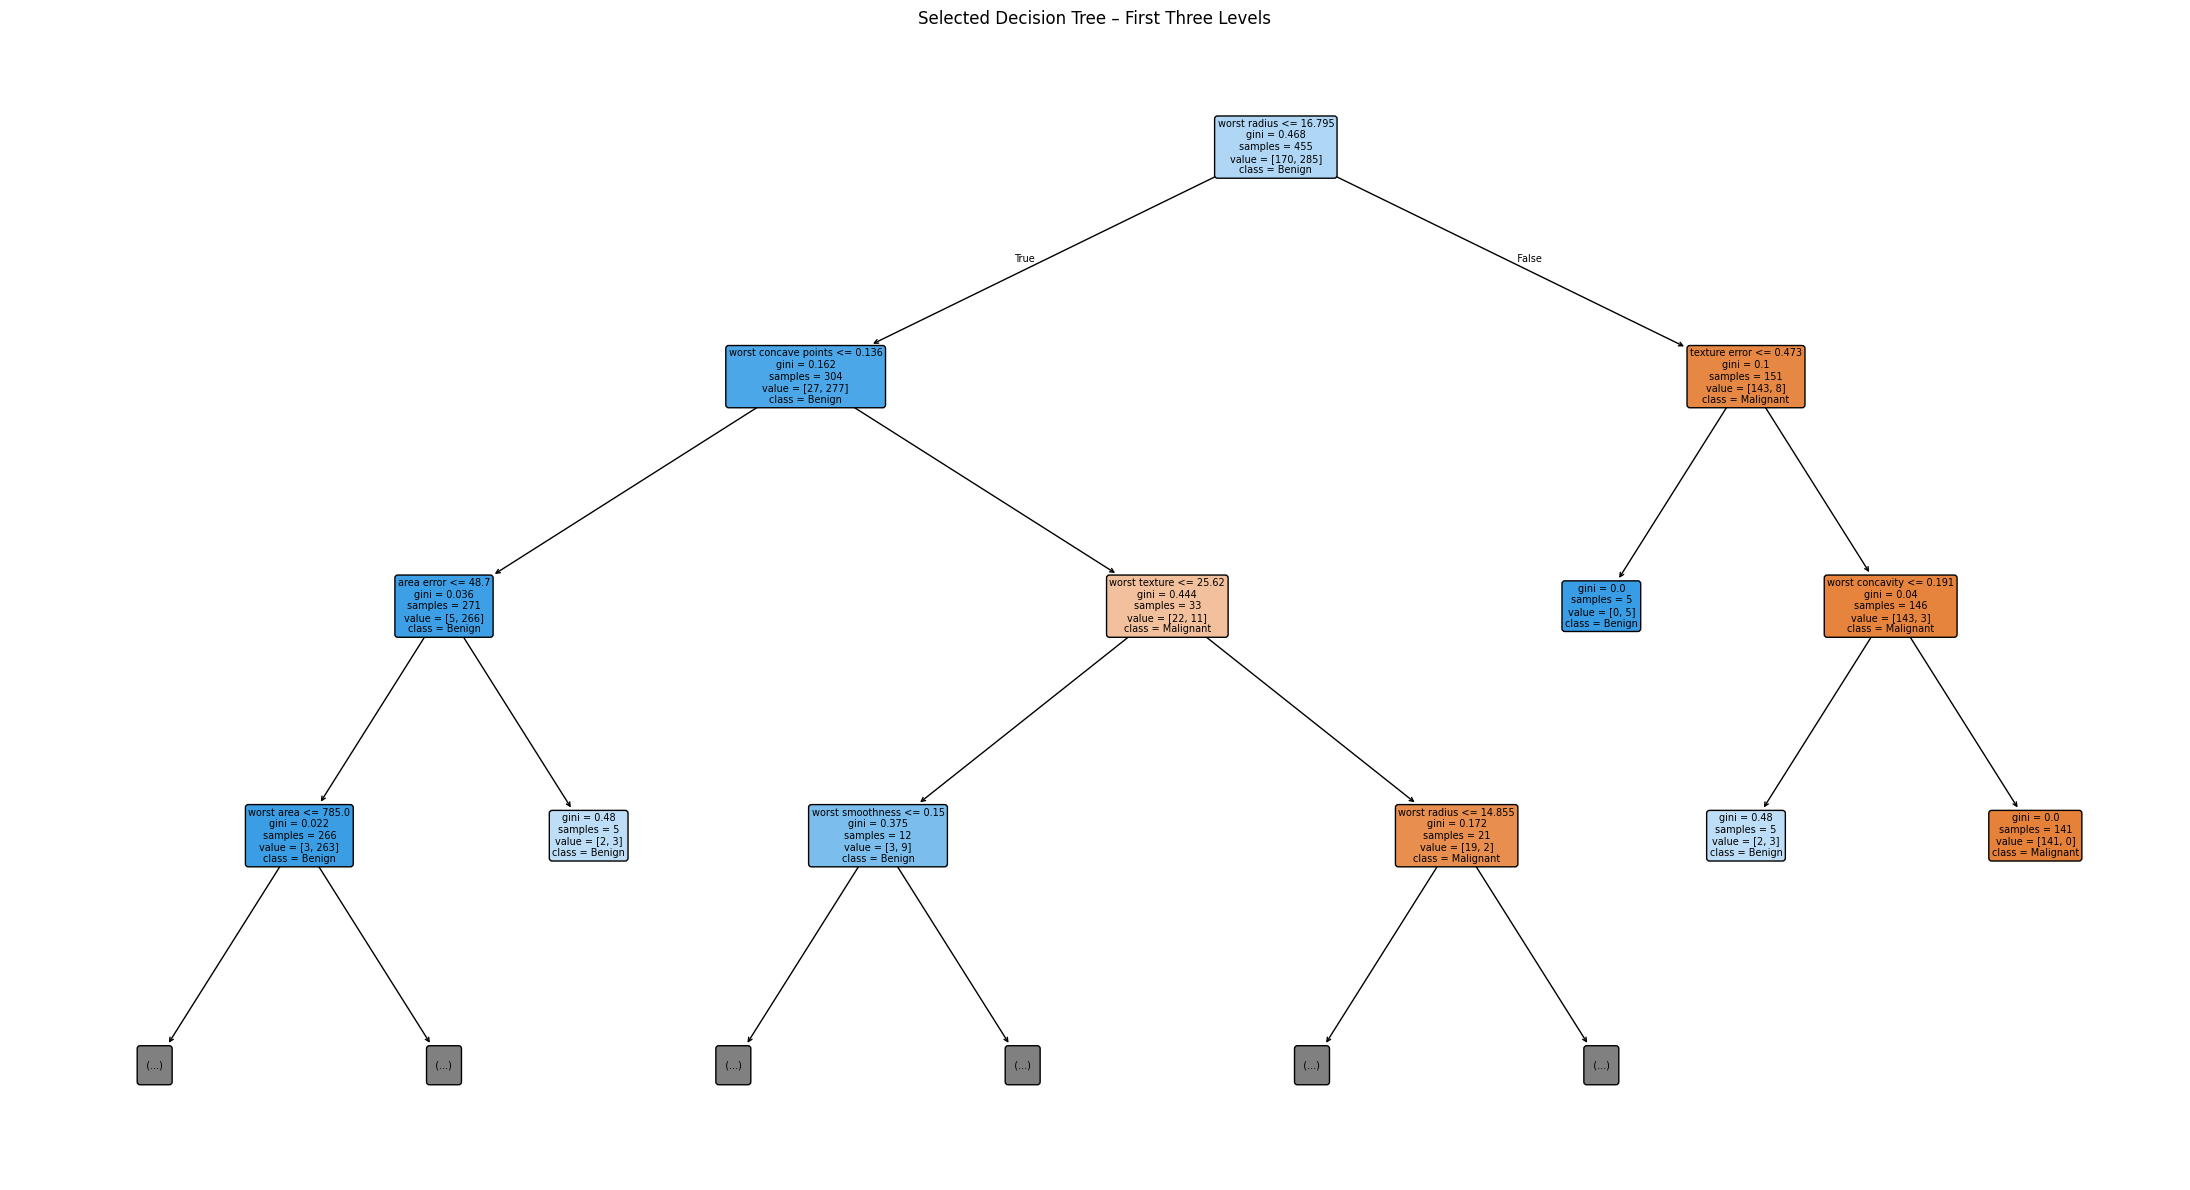

In [11]:
best_dt = dt_grid.best_estimator_
best_dt.fit(X_train,y_train)
dt_pred = best_dt.predict(X_test)
dt_prob = best_dt.predict_proba(X_test)[:,1]
dt_result = metrics_row("Decision Tree",y_test,dt_pred,dt_prob)
display(pd.DataFrame([dt_result]))

plt.figure(figsize=(22,12))
plot_tree(best_dt, feature_names=X.columns, class_names=["Malignant","Benign"],
          filled=True, rounded=True, max_depth=3, fontsize=7)
plt.title("Selected Decision Tree – First Three Levels")
plt.tight_layout()
plt.savefig(FIG_DIR/"decision_tree_visualization.png",dpi=300,bbox_inches="tight")
plt.show()


## 12. Random Forest – 5-Fold Hyperparameter Search

In [12]:
rf = RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1)
rf_grid_params = {
    "n_estimators": [50,100,200],
    "max_depth": [None,5,10,15],
    "max_features": ["sqrt","log2",None],
    "bootstrap": [True,False]
}

rf_grid = GridSearchCV(
    rf, rf_grid_params,
    scoring={"accuracy":"accuracy","f1":"f1"},
    refit="f1", cv=cv, n_jobs=-1, return_train_score=True
)
rf_grid.fit(X_train,y_train)

print("Best parameters:", rf_grid.best_params_)
print("Best mean CV F1:", rf_grid.best_score_)

rf_cv = pd.DataFrame(rf_grid.cv_results_)
rf_table = rf_cv[[
    "param_n_estimators","param_max_depth","param_max_features",
    "param_bootstrap","mean_test_accuracy","mean_test_f1",
    "std_test_accuracy","std_test_f1"
]].sort_values("mean_test_f1",ascending=False)
display(rf_table.head(15))


Best parameters: {'bootstrap': True, 'max_depth': None, 'max_features': 'log2', 'n_estimators': 100}
Best mean CV F1: 0.9718007446140527


,param_n_estimators,param_max_depth,param_max_features,param_bootstrap,mean_test_accuracy,mean_test_f1,std_test_accuracy,std_test_f1
4,100,None,log2,True,0.964835,0.971801,0.018906,0.015323
22,100,10,log2,True,0.964835,0.971801,0.018906,0.015323
31,100,15,log2,True,0.964835,0.971801,0.018906,0.015323
59,200,10,log2,False,0.962637,0.970332,0.020382,0.016363
41,200,None,log2,False,0.962637,0.970332,0.020382,0.016363
68,200,15,log2,False,0.962637,0.970332,0.020382,0.016363
66,50,15,log2,False,0.962637,0.970243,0.020382,0.016342
39,50,None,log2,False,0.962637,0.970243,0.020382,0.016342
57,50,10,log2,False,0.962637,0.970243,0.020382,0.016342
29,200,15,sqrt,True,0.962637,0.970027,0.017855,0.014628


## 13. Random Forest – Number of Estimators

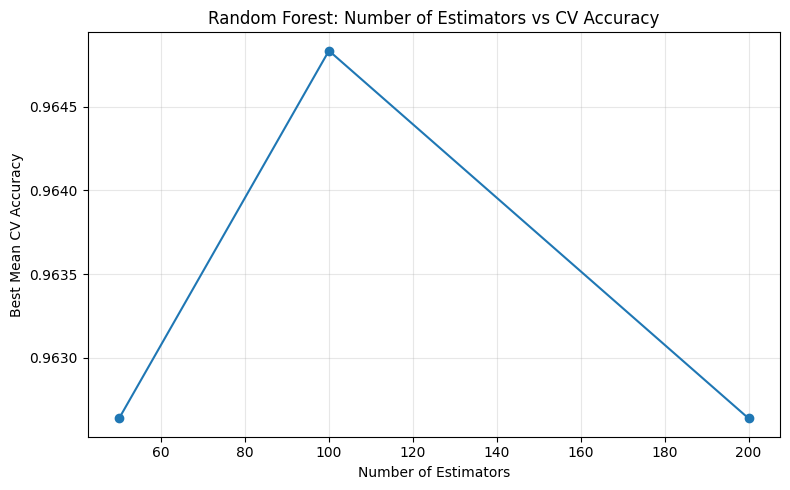

In [13]:
est_effect = rf_cv.groupby("param_n_estimators")["mean_test_accuracy"].max().reset_index()

plt.figure(figsize=(8,5))
plt.plot(est_effect["param_n_estimators"].astype(int),est_effect["mean_test_accuracy"],marker="o")
plt.xlabel("Number of Estimators")
plt.ylabel("Best Mean CV Accuracy")
plt.title("Random Forest: Number of Estimators vs CV Accuracy")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/"random_forest_estimators_effect.png",dpi=300,bbox_inches="tight")
plt.show()


**Inference:** Increasing the number of trees can stabilize Random Forest predictions by averaging more randomized learners. After sufficient trees, performance may show diminishing returns. Maximum depth, feature subsampling, and bootstrap sampling also affect the diversity and complexity of the forest.

## 14. Final Random Forest

In [14]:
best_rf = rf_grid.best_estimator_
best_rf.fit(X_train,y_train)
rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:,1]
rf_result = metrics_row("Random Forest",y_test,rf_pred,rf_prob)
display(pd.DataFrame([rf_result]))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.95614,0.958904,0.972222,0.965517,0.992394


## 15. Five-Fold Accuracy Comparison

In [23]:
dt_cv_scores = cross_val_score(best_dt, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
rf_cv_scores = cross_val_score(best_rf, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)

cv_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Fold 1": [dt_cv_scores[0], rf_cv_scores[0]],
    "Fold 2": [dt_cv_scores[1], rf_cv_scores[1]],
    "Fold 3": [dt_cv_scores[2], rf_cv_scores[2]],
    "Fold 4": [dt_cv_scores[3], rf_cv_scores[3]],
    "Fold 5": [dt_cv_scores[4], rf_cv_scores[4]],
    "Average": [dt_cv_scores.mean(), rf_cv_scores.mean()],
    "Std": [dt_cv_scores.std(), rf_cv_scores.std()]
})

# Select all columns except the string-based "Model" column
numeric_cols = cv_comparison.columns.drop("Model")

# Apply the float formatting only to the numeric columns
display(cv_comparison.style.format("{:.4f}", subset=numeric_cols))

,Model,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Average,Std
0,Decision Tree,0.9451,0.9451,0.9121,0.9231,0.9670,0.9385,0.0192
1,Random Forest,0.9670,0.9780,0.9341,0.9560,0.9890,0.9648,0.0189


## 16. Confusion Matrices

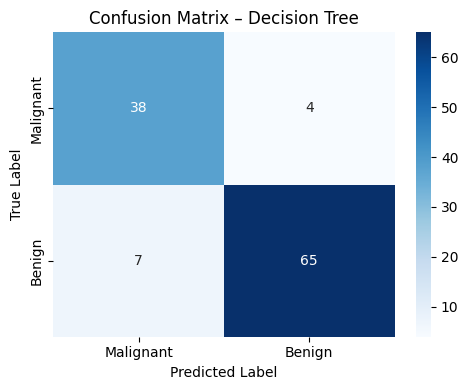

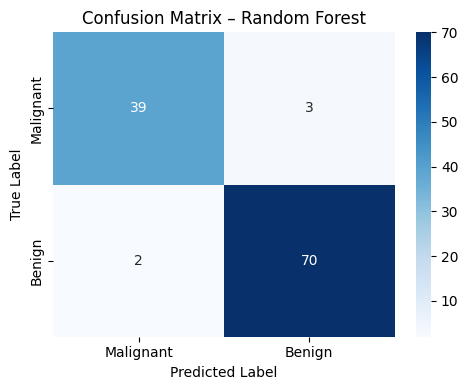

In [16]:
for name,pred in {"Decision Tree":dt_pred,"Random Forest":rf_pred}.items():
    cm = confusion_matrix(y_test,pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",
                xticklabels=["Malignant","Benign"],
                yticklabels=["Malignant","Benign"])
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    filename = name.lower().replace(" ","_")+"_confusion_matrix.png"
    plt.savefig(FIG_DIR/filename,dpi=300,bbox_inches="tight")
    plt.show()


**Inference:** Confusion matrices show correct predictions on the diagonal and misclassifications off the diagonal. They reveal class-specific errors that are not captured by accuracy alone. Precision, recall, and F1-score should therefore be interpreted together with these matrices.

## 17. ROC Curves and AUC

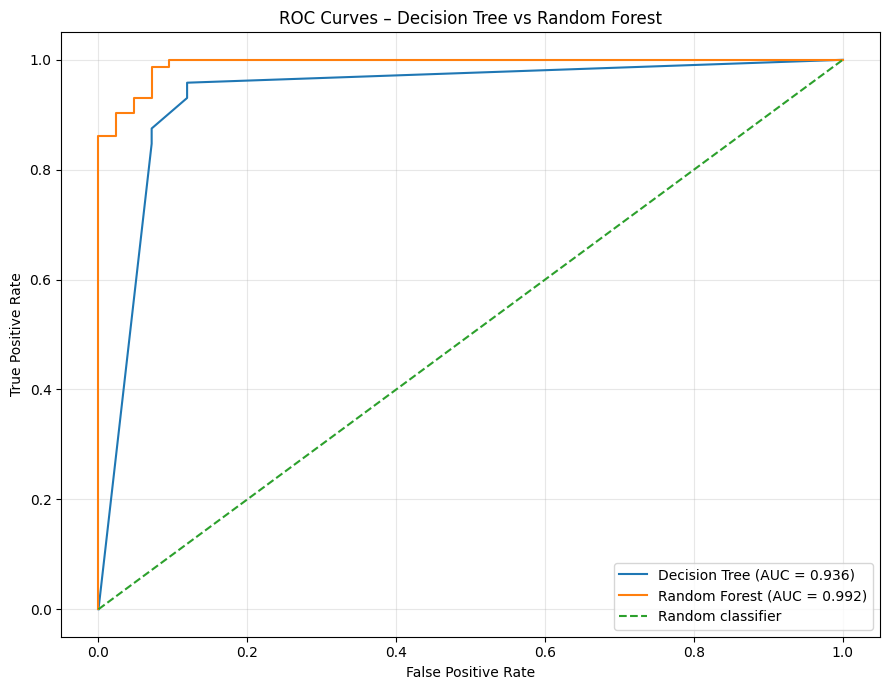

In [17]:
plt.figure(figsize=(9,7))
for name,prob in [("Decision Tree",dt_prob),("Random Forest",rf_prob)]:
    fpr,tpr,_ = roc_curve(y_test,prob)
    score = auc(fpr,tpr)
    plt.plot(fpr,tpr,label=f"{name} (AUC = {score:.3f})")
plt.plot([0,1],[0,1],"--",label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Decision Tree vs Random Forest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR/"roc_curves.png",dpi=300,bbox_inches="tight")
plt.show()


## 18. Random Forest Feature Importance

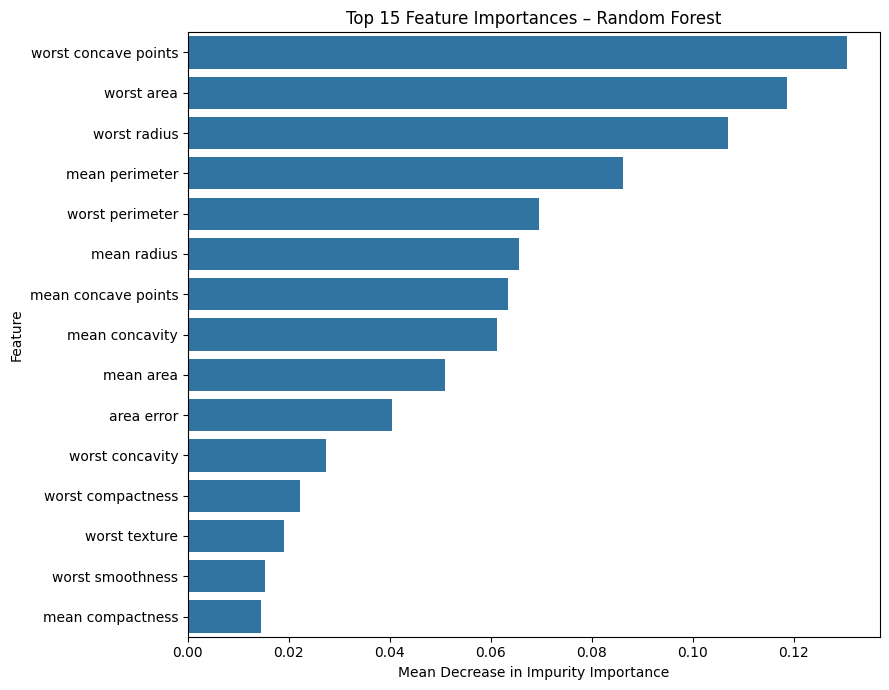

,Feature,Importance
27,worst concave points,0.130588
23,worst area,0.118600
20,worst radius,0.107072
2,mean perimeter,0.086259
22,worst perimeter,0.069519
0,mean radius,0.065605
7,mean concave points,0.063443
6,mean concavity,0.061326
3,mean area,0.050850
13,area error,0.040344


In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance",ascending=False).head(15)

plt.figure(figsize=(9,7))
sns.barplot(data=importance,x="Importance",y="Feature")
plt.title("Top 15 Feature Importances – Random Forest")
plt.xlabel("Mean Decrease in Impurity Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIG_DIR/"random_forest_feature_importance.png",dpi=300,bbox_inches="tight")
plt.show()
display(importance)


**Inference:** The feature-importance plot identifies predictors that contribute strongly to the fitted Random Forest's splitting decisions. These are model-specific importance values and should not be interpreted as causal effects. Random feature selection and aggregation allow the forest to distribute decisions across many trees.

## 19. Final Evaluation Metrics

In [19]:
results = pd.DataFrame([dt_result,rf_result])
display(results.style.format({
    "Accuracy":"{:.4f}","Precision":"{:.4f}","Recall":"{:.4f}",
    "F1 Score":"{:.4f}","ROC-AUC":"{:.4f}"
}))


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Decision Tree,0.9035,0.9420,0.9028,0.9220,0.9358
1,Random Forest,0.9561,0.9589,0.9722,0.9655,0.9924


## 20. Training vs Test Accuracy – Overfitting Diagnostic

In [24]:
rows = []
for name, model in [("Decision Tree", best_dt), ("Random Forest", best_rf)]:
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    rows.append({
        "Model": name,
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Train-Test Gap": train_acc - test_acc
    })

train_test = pd.DataFrame(rows)

# Select all columns except the string-based "Model" column
numeric_cols = train_test.columns.drop("Model")

# Apply the float formatting only to the numeric columns
display(train_test.style.format("{:.4f}", subset=numeric_cols))

,Model,Train Accuracy,Test Accuracy,Train-Test Gap
0,Decision Tree,0.9758,0.9035,0.0723
1,Random Forest,1.0000,0.9561,0.0439


### Interpretation
A large training-test accuracy gap can indicate overfitting. Decision Trees can become high-variance when they grow too deeply. Random Forest generally reduces variance through bootstrap sampling, random feature selection, and aggregation. The train-test gap is a practical diagnostic, not a direct statistical estimate of bias or variance.

## 21. Observation Questions

### 1. How does tree depth affect overfitting?
Increasing depth permits more complex rules. Shallow trees may underfit, while very deep trees can fit noise and training-specific patterns, increasing variance. Cross-validation helps select a suitable complexity.

### 2. Which hyperparameter had the greatest impact?
Determine this from the generated GridSearchCV tables. For the Decision Tree, compare criterion, max depth, minimum samples split, and minimum samples leaf. For Random Forest, compare n estimators, max depth, max features, and bootstrap.

### 3. How does Random Forest improve generalization?
It trains many randomized trees and aggregates their predictions. Bootstrap samples and random feature subsets reduce correlation between trees, so aggregation reduces the influence of individual high-variance trees.

### 4. Did ensemble learning always improve performance?
Not necessarily. Compare the actual cross-validation and held-out test metrics. An ensemble may improve stability or some metrics without improving every metric on a particular finite test set.

## 22. Conclusion

Decision Tree and Random Forest classifiers were implemented and evaluated on the Wisconsin Diagnostic Breast Cancer dataset. Hyperparameters were selected using stratified 5-fold cross-validation and final performance was evaluated on a held-out 20% test set. The experiment demonstrates how tree depth affects overfitting and how Random Forest reduces variance through bootstrap sampling, random feature selection, and aggregation. The final conclusion should be based on the numerical results produced by the notebook.

## 23. References

1. Scikit-learn, Decision Trees: https://scikit-learn.org/stable/modules/tree.html  
2. Scikit-learn, Ensemble Methods / Random Forest: https://scikit-learn.org/stable/modules/ensemble.html  
3. UCI Machine Learning Repository: https://archive.ics.uci.edu/  
4. F. Pedregosa et al., “Scikit-learn: Machine Learning in Python,” Journal of Machine Learning Research, vol. 12, pp. 2825–2830, 2011.

## 24. Export Results

In [21]:
results.to_csv(FIG_DIR/"final_model_results.csv",index=False)
dt_table.head(15).to_csv(FIG_DIR/"decision_tree_cv_results.csv",index=False)
rf_table.head(15).to_csv(FIG_DIR/"random_forest_cv_results.csv",index=False)
cv_comparison.to_csv(FIG_DIR/"five_fold_accuracy_comparison.csv",index=False)
train_test.to_csv(FIG_DIR/"train_test_overfitting_diagnostic.csv",index=False)
print("Figures and tables saved to:",FIG_DIR.resolve())


Figures and tables saved to: /content/figures
